# 02 · Basics

The **Introduction** notebook covered individual pulse sequences. This notebook shows how to repeat a sequence and vary its parameters. You will declare **variables**, define their values with **sweep sources**, and use **`average(shots)`** to average repeated measurements.

You will also retrieve, inspect, and plot measurement results. `qp.simulate` returns labelled arrays with dimensions and coordinates derived from the variables you sweep.

The worked examples demonstrate a single sweep, two nested sweeps, and two sweeps that advance together. They use simple measurement models on the reference platform.

As in **Introduction**, the examples use the waveform aliases `"readout"` and `"weights"`. They remain unresolved here because the reference platform generates data from the measurement model without evaluating the readout waveforms.

In [1]:
# Install QProgram if it is not already available in this Python environment.
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "qprogram[viz]==0.2.0"], check=True)
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.2.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import qprogram as qp
from qprogram import MeasurementField
from qprogram.buses import BusSchema
from qprogram.plotting import Quantity, Style
from qprogram.waveforms import IQDrag, IQZero, Square

schema = BusSchema.transmon()
q = schema.q

## 2.1 Variables

A variable represents a numeric value that can be assigned later or changed between iterations. Declare one when you want to reuse a program with different parameter values.

You can assign a value directly with `set_value()` and clear it with `reset()`. A sweep assigns successive values automatically. The example below demonstrates these changes before introducing loops.

In [3]:
scratch = qp.QProgram(label="variables", schema=schema)
amp = scratch.variable("amp")

print("initial value:", amp.value)
amp.set_value(0.25)  # Assign a value directly; a sweep does this for each iteration.
print("after set_value:", amp.value)
amp.reset()
print("after reset:", amp.value)

initial value: UNASSIGNED
after set_value: 0.25
after reset: UNASSIGNED


### Declaring a variable

Use `program.variable(id, *, label=None, units=None, description=None)` to declare a variable. The `id` is required; the remaining arguments are optional and must be passed by keyword.

The identifier appears in the `.qp` file and names the corresponding result dimension when the variable is swept. It must match `[A-Za-z_][A-Za-z0-9_]*`, be unique within the program, and avoid the words in `qp.RESERVED_KEYWORDS`. Invalid or duplicate identifiers are rejected when you declare the variable.

Use `label` for a readable name and `units` for the unit of the values. Both are stored on the result coordinate and used to label plots automatically. The optional `description` provides further explanation in the saved program; it is not used for result or plot labels.

In [4]:
freq = scratch.variable(
    "freq", label="Readout frequency", units="Hz", description="Frequency used for the readout signal."
)

print("id:", freq.id)  # Used in the program text and result dimensions.
print("label:", freq.label)  # Used for a readable plot label.
print("units:", freq.units)

id: freq
label: Readout frequency
units: Hz


In [5]:
# This program already has a variable with the identifier "freq".
try:
    scratch.variable("freq")
except qp.ValidationError as exc:
    print(exc)

Variable 'freq' is already declared on this QProgram


In [6]:
# Identifiers cannot contain spaces. Use label= for a readable name with spaces.
try:
    scratch.variable("readout frequency")
except qp.InvalidVariableIdError as exc:
    print(exc)

Variable id 'readout frequency' is invalid: must match [A-Za-z_][A-Za-z0-9_]* (letters, digits, underscores only; cannot start with a digit, no spaces or special characters). Use the optional `label` for human-readable names.


## 2.2 Expressions

Operations on variables create symbolic expressions. They record the calculation to perform and are evaluated later using the variables' current values.

QProgram supports the following expression operations:

- Arithmetic: `+`, `-`, `*`, and `/`, including forms such as `2 * amp`. These create a `BinaryOp`. Power, floor division, and modulo are not supported.
- Unary operators: `-amp` and `+amp`, which create a `UnaryOp`.
- Mathematical functions: `abs()`, `qp.sin`, `qp.cos`, `qp.tan`, `qp.exp`, `qp.log`, `qp.sqrt`, `qp.minimum`, and `qp.maximum`, which create a `MathFunc`.
- Comparisons: `<`, `<=`, `>`, and `>=`, which create a `Comparison`. Use `qp.where(condition, then, else_)` to select a value based on a condition.
- Logical operators: `&`, `|`, and `~`, which create a `LogicalBinaryOp` or `LogicalNot`.

For symbolic equality and inequality between variables, use `qp.eq` and `qp.ne`. A variable's `==` operator returns a Python boolean for object comparison. The measurement state proxy has a different interface: it supports expressions such as `handle.state == 1`, used in **Advanced**.

A symbolic expression cannot be used as a Python truth value. For example, `if amp > 0.5:` raises `TypeError`, as shown below.

In [7]:
sketch = qp.QProgram(label="expressions", schema=schema)
detuning = sketch.variable("detuning", label="Detuning", units="Hz")
delay = sketch.variable("delay", label="Delay", units="ns")

# These expressions are stored in the program and evaluated when values are assigned.
sketch.set_frequency(q[0].readout, detuning + 7.20e9)
sketch.wait(q[0].readout, 4 * delay)

print(qp.dumps(sketch))

#!QProgram 0.2

metadata:
  label: "expressions"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var detuning label="Detuning" units="Hz"
  var delay label="Delay" units="ns"

  set_frequency q[0].readout (detuning + 7200000000.0)
  wait q[0].readout (4 * delay)



In [8]:
# A symbolic comparison cannot decide which branch Python should execute now.
try:
    if amp > 0.5:
        pass
except TypeError as exc:
    print(exc)

Expression has no truth value — use .evaluate()/.evaluate_or_raise() to compute it, or qprogram.where(cond, then, else_) to build a conditional expression.


### Using and evaluating expressions

Expressions can replace numeric arguments in operations such as `set_frequency`, `set_gain`, `set_phase`, `set_offset`, `set_parameter`, and `wait`.

They can also be used in numeric constructor arguments of parameterised waveforms. Exceptions include the sample array passed to `Arbitrary`, the waveform object passed to a wrapper, and the integer `buffer` of `FlatTop`.

To vary a pulse, pass the expression through its waveform constructor. The waveform evaluates the expression when `envelope()` is called. Section 2.8 uses this approach to sweep a pulse's amplitude.

Use `evaluate()` to inspect an expression's current value. It returns `qp.UNASSIGNED` if any required variable has no value. Use `evaluate_or_raise()` when evaluation must produce a number. The interpreter uses this stricter method during execution, so an unassigned variable raises an error.

In [9]:
tone = Square(amplitude=amp / 2, duration=8)
amp.set_value(0.8)
print("envelope with amp=0.8:", tone.envelope())
amp.reset()
print("amplitude expression after reset:", tone.amplitude.evaluate())

envelope with amp=0.8: [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
amplitude expression after reset: UNASSIGNED


In [10]:
# Execution requires a value for every variable used by an operation.
orphan = qp.QProgram(label="unbound", schema=schema)
loose = orphan.variable("loose")
orphan.set_gain(q[0].readout, loose)  # This variable remains unassigned when the program runs.
try:
    qp.simulate(orphan)
except qp.UnassignedVariableError as exc:
    print(exc)

Cannot evaluate expression Variable('loose'): unassigned variable(s) {Variable('loose')}


## 2.3 Sweeps

Use `program.sweep(variable, source)` to execute a block once for each value supplied by a source. Before each iteration, the sweep assigns the next value to the variable. Operations inside the block then use that value.

A **sweep source** defines the values and how they are generated. It is stored in the `.qp` file and declares the capabilities needed to execute it. The same `sweep` interface works with different sources, including ranges and explicit lists of values.

In [11]:
tiny = qp.QProgram(label="smallest_sweep", schema=schema)
gain = tiny.variable("gain")

with tiny.sweep(gain, qp.Values([0.1, 0.2, 0.3])):
    tiny.set_gain(q[0].readout, gain)

print(qp.dumps(tiny))

#!QProgram 0.2

metadata:
  label: "smallest_sweep"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var gain

  for gain in [0.1, 0.2, 0.3]:
    set_gain q[0].readout gain



### Two ways to define a sweep

You can pass a source object to `sweep`, as above, or use a `from_*` builder method. For example, `sweep(gain).from_values([0.1, 0.2, 0.3])` creates the same sweep as passing `qp.Values([0.1, 0.2, 0.3])` directly.

The builder methods are resolved through the sweep-source registry, so registered extensions can provide additional `from_<name>` methods. Both forms create the same program structure and `.qp` text. Use whichever is clearer for your example; an explicit source object is useful when you want to reuse or inspect it.

Passing a plain list directly to `sweep` is not supported. Wrap it in `qp.Values` or use `from_values`, so the source can declare its type and required capabilities.

In [12]:
fluent = qp.QProgram(label="smallest_sweep", schema=schema)
g_fluent = fluent.variable("gain")
with fluent.sweep(g_fluent).from_values([0.1, 0.2, 0.3]):
    fluent.set_gain(q[0].readout, g_fluent)

print(qp.dumps(fluent))  # The builder produces the same sweep as qp.Values above.
print("same program structure:", tiny.body == fluent.body)

#!QProgram 0.2

metadata:
  label: "smallest_sweep"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var gain

  for gain in [0.1, 0.2, 0.3]:
    set_gain q[0].readout gain

same program structure: True


In [13]:
# A plain list does not identify a sweep-source type.
try:
    with tiny.sweep(gain, [0.1, 0.2, 0.3]):
        pass
except qp.ValidationError as exc:
    print(exc)

Sweep source must be a SweepSource, got [0.1, 0.2, 0.3]


### Available sweep sources

QProgram provides eight sweep sources, each available as a source object or through the builder interface.

| Source | Purpose |
|---|---|
| `qp.Range(start, stop, step=1)` | Generate values with a specified step size. |
| `qp.Linspace(start, stop, num)` | Generate a specified number of evenly spaced values. |
| `qp.Values(points)` | Use explicit values supplied as an array-like object accepted by `numpy.asarray`. |
| `qp.Logspace(start, stop, num)` | Generate logarithmically spaced values between the supplied bounds, which are values rather than exponents. |
| `qp.File(path)` | Read values from a `.npy` file. The source stores the path and reads the file on each access. |
| `qp.Repeat(source, times)` | Repeat another source the specified number of times. |
| `qp.Rotate(source, by=1)` | Shift another source cyclically to the left. |
| `qp.Concat(sources)` | Concatenate several sources. |

`Repeat`, `Rotate`, and `Concat` combine or transform existing sources. Their outputs are also sources, so you can combine them further. The builder interface also supports chained `.rotate(by=...)` and `.repeat(...)` calls.

In [14]:
base = qp.Values([0.0, 0.5, 1.0])
print("explicit values:", base.values())

# Range specifies a step; Linspace specifies the number of points.
stepped = qp.Range(0.0, 1.0, 0.25)
print("Range:", stepped.values())
print("number of points:", stepped.length())
print("Linspace:", qp.Linspace(0.0, 1.0, 5).values())

# Logspace uses logarithmic spacing between the supplied bounds.
print("Logspace:", qp.Logspace(0.01, 1.0, 5).values())

# Combinators reuse the values from an existing source.
print("Repeat:", qp.Repeat(base, times=2).values())  # Repeat the whole sequence twice.
print("Rotate:", qp.Rotate(base, by=1).values())  # Move the first value to the end.
print("Concat:", qp.Concat([base, qp.Values([2.0, 3.0])]).values())  # Append another source.

explicit values: [0.  0.5 1. ]
Range: [0.   0.25 0.5  0.75 1.  ]
number of points: 5
Linspace: [0.   0.25 0.5  0.75 1.  ]
Logspace: [0.01       0.03162278 0.1        0.31622777 1.        ]
Repeat: [0.  0.5 1.  0.  0.5 1. ]
Rotate: [0.5 1.  0. ]
Concat: [0.  0.5 1.  2.  3. ]


## 2.4 Measurement models

The reference platform calls a **measurement model** for each measurement at each shot and sweep point. The model receives the bus and an `env` mapping. This mapping contains currently assigned variable values, keyed by identifier, and platform parameter values, keyed as `"bus.parameter"`. Unassigned variables are absent from `env`.

`qp.MockMeasurementModel(response=None, p_excited=None, noise=0.0, raw_samples=16, seed=0)` provides a configurable model:

- `response` returns the noiseless complex I/Q value. The default is `0j`.
- `p_excited` returns the probability of state 1. By default, every shot is in state 0.
- `noise` sets the standard deviation of Gaussian noise added to each quadrature per shot.
- `raw_samples` sets the length of the simulated raw trace.
- `seed` initialises the model's random number generator. Creating a new model with the same seed reproduces the sequence; reusing an existing model continues its random sequence.

The example below prints the arguments received by a response function at two frequency points. Each call receives the current value of `ro_freq` in `env`.

In [15]:
def show_environment(bus, env):
    """Show the model's inputs and return a constant I/Q response."""
    print("bus:", bus)
    print("env:", env)
    return 1 + 0j


probe = qp.QProgram(label="env_probe", schema=schema)
p_freq = probe.variable("ro_freq", units="Hz")

with probe.sweep(p_freq, qp.Values([7.19e9, 7.21e9])):
    probe.set_frequency(q[0].readout, p_freq)
    probe.measure(q[0].readout, "readout", "weights")

# One measurement at each frequency produces two calls to show_environment.
probe_result = qp.simulate(probe, model=qp.MockMeasurementModel(response=show_environment))

bus: q0/readout
env: {'ro_freq': 7190000000.0}
bus: q0/readout
env: {'ro_freq': 7210000000.0}


### Defining a custom model

To define your own measurement model, implement `sample(bus, env)` and return a `qp.MeasurementSample`. The sample contains `i`, `q`, `state`, and an optional `raw` trace. If your model returns raw traces, provide a `raw_samples` attribute so the executor can determine their length at the start of the run.

A custom model is useful when measurements depend on earlier samples, share state across buses, or require a relationship between the classified state and I/Q values. The example below chooses the state first, then samples I/Q values from the distribution associated with that state. Its `p_excited` argument is a fixed probability between 0 and 1.

In [16]:
class TwoStateReadout:
    """Sample I/Q values from a distribution selected by the sampled qubit state."""

    def __init__(self, p_excited, seed=0):
        self.p_excited = p_excited
        self.rng = np.random.default_rng(seed)

    def sample(self, bus, env):
        # Choose state 1 with probability p_excited; otherwise choose state 0.
        state = int(self.rng.random() < self.p_excited)

        # Each state has its own mean I/Q response.
        if state == 1:
            centre_i, centre_q = 0.9, 0.1
        else:
            centre_i, centre_q = 0.2, -0.3

        noise_i, noise_q = self.rng.normal(0.0, 0.08, size=2)
        return qp.MeasurementSample(
            i=centre_i + noise_i,
            q=centre_q + noise_q,
            state=state,
        )


one_point = qp.QProgram(label="own_model", schema=schema)
m_own = one_point.measure(
    q[0].readout, "readout", "weights", fields=(MeasurementField.IQ, MeasurementField.STATE)
)
own_model = TwoStateReadout(p_excited=1.0, seed=1)  # Always choose state 1 in this example.
own = qp.simulate(one_point, model=own_model)

print("I/Q sample for state 1:", own.get(m_own).values)
print("classified state:", own.get(m_own, field=MeasurementField.STATE).item())

I/Q sample for state 1: [0.96572945 0.12643497]
classified state: 1.0


## 2.5 Averaging measurements

Use `with program.average(shots=N):` to repeat a block `N` times and average its measurement outputs. Integrated I/Q values and raw traces are averaged over the shots. Classified states are averaged to estimate the probability of state 1.

Averaging does not add a shot dimension to the result. It does, however, add a level of loop nesting. A platform's `max_loop_nesting` capability therefore applies to averaging blocks as well as sweeps, as explained in **Advanced**.

The next two cells compare a 64-point scan with one shot per point and the same scan with 256 shots averaged per point. The model supplies a constant I/Q response with added noise and a state-1 probability of 0.3. Both programs request I/Q and classified states so we can inspect how each output is averaged.

In [17]:
P_EXCITED = 0.3  # State-1 probability assumed by the model.

averaging_model = qp.MockMeasurementModel(
    response=lambda bus, env: 1 + 0j,  # Mean I=1 and Q=0 at every point.
    p_excited=lambda bus, env: P_EXCITED,
    noise=0.5,  # Noise standard deviation in each quadrature for a single shot.
    seed=5,
)

single_shot = qp.QProgram(label="single_shot_scan", schema=schema)
single_index = single_shot.variable("idx")

# Without average(), each point contains one measurement sample.
with single_shot.sweep(single_index, qp.Range(0, 63)):
    m_single_shot = single_shot.measure(
        q[0].readout, "readout", "weights", fields=(MeasurementField.IQ, MeasurementField.STATE)
    )

single_result = qp.simulate(single_shot, model=averaging_model)
single_iq = single_result.get(m_single_shot)

In [18]:
averaged = qp.QProgram(label="averaged_scan", schema=schema)
average_index = averaged.variable("idx")

# Repeat the same scan 256 times and average the measurements at each point.
with averaged.average(shots=256):
    with averaged.sweep(average_index, qp.Range(0, 63)):
        m_averaged = averaged.measure(
            q[0].readout, "readout", "weights", fields=(MeasurementField.IQ, MeasurementField.STATE)
        )

# Reusing the model draws new samples from the same distributions.
average_result = qp.simulate(averaged, model=averaging_model)
averaged_iq = average_result.get(m_averaged)

print("one shot:", single_iq.dims, single_iq.shape)
print("256 shots:", averaged_iq.dims, averaged_iq.shape)  # The shape is unchanged.

single_i = single_iq.sel(IQ="I")
averaged_i = averaged_iq.sel(IQ="I")
print("single-shot I standard deviation:", single_i.std().item())
print("averaged I standard deviation:", averaged_i.std().item())

one shot: ('idx', 'IQ') (64, 2)
256 shots: ('idx', 'IQ') (64, 2)
single-shot I standard deviation: 0.5473215026602651
averaged I standard deviation: 0.030293847907234887


The result dimensions and shape stay the same for both shot counts. Increasing the number of shots reduces the variation in the averaged signal. For independent noise, the standard deviation of the mean decreases approximately as `1 / sqrt(shots)`.

For `MeasurementField.STATE`, one shot produces a value of 0 or 1 at each point. Averaging many shots produces a fraction between 0 and 1. The next cell retrieves the states from the same two runs and prints the first five points. The averaged values estimate the model's state-1 probability, `P_EXCITED = 0.3`.

In [19]:
single_states = single_result.get(m_single_shot, field=MeasurementField.STATE)
averaged_states = average_result.get(m_averaged, field=MeasurementField.STATE)

# Show the first five points: individual states versus estimated probabilities.
print("one shot:", single_states.values[:5])
print("256 shots:", averaged_states.values[:5])
print("model probability:", P_EXCITED)

one shot: [0. 0. 0. 1. 0.]
256 shots: [0.30078125 0.28125    0.30078125 0.20703125 0.28125   ]
model probability: 0.3


## 2.6 One swept variable

This example combines a variable, a sweep, averaging, and a measurement model. It sweeps the readout frequency from 7.19 to 7.21 GHz in 200 kHz steps and averages 200 shots at each point.

The `s21` response function uses two constants to describe the simulated resonator. `F_READOUT` is its assumed true resonance frequency, set to 7.20 GHz. `KAPPA` is its linewidth parameter in hertz, set to 1.5 MHz. We define both next to the model so their meaning is clear.

`ro_freq` is the frequency varied by the program, while `F_READOUT` stays fixed in the model. Later, we will compare the frequency estimated from the simulated measurements with this known reference value.

In [20]:
F_READOUT = 7.20e9  # Hz; true resonator frequency assumed by the mock model.
KAPPA = 1.5e6  # Hz; resonator linewidth parameter.


def s21(bus, env):
    """Return a transmission response centred at F_READOUT with linewidth KAPPA."""
    delta = (env["ro_freq"] - F_READOUT) / (KAPPA / 2)
    return 1.0 - 0.9 / (1.0 + 1j * delta)


spectroscopy = qp.QProgram(
    label="resonator_spectroscopy",
    description="Sweep the readout frequency and average the integrated response.",
    schema=schema,
)
ro_freq = spectroscopy.variable("ro_freq", label="Readout frequency", units="Hz")

with spectroscopy.average(shots=200):
    with spectroscopy.sweep(ro_freq, qp.Range(7.19e9, 7.21e9, 0.2e6)):
        spectroscopy.set_frequency(q[0].readout, ro_freq)
        m_spec = spectroscopy.measure(q[0].readout, "readout", "weights")

print(qp.dumps(spectroscopy))

#!QProgram 0.2

metadata:
  label: "resonator_spectroscopy"
  description: "Sweep the readout frequency and average the integrated response."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var ro_freq label="Readout frequency" units="Hz"

  average 200:
    for ro_freq in Range(start=7190000000.0, stop=7210000000.0, step=200000.0):
      set_frequency q[0].readout ro_freq
      measure q[0].readout "readout" "weights" name="q0/readout/m0"



In [21]:
result = qp.simulate(spectroscopy, model=qp.MockMeasurementModel(response=s21, noise=0.02, seed=7))
iq = result.get(m_spec)

print("dims:", iq.dims, "shape:", iq.shape)

dims: ('ro_freq', 'IQ') shape: (101, 2)


The array has 101 frequency points and two quadratures. The 200 shots have been averaged at each point, so there is no shot dimension.

### Understanding the result object

`qp.simulate` returns a `qp.QProgramResult`. It contains one record for each `measure` operation, in declaration order. Each record identifies the bus, measurement name, and requested output fields.

In [22]:
print(result)

# This program contains one measure operation, so its result has one record.
record = result.measurements[0]
print("bus:", record.bus)
print("measurement name:", record.name)
print("fields:", list(record.fields))  # Field names only; retrieve the arrays with result.get.

QProgramResult(1 measurements, names=['q0/readout/m0'])
bus: q0/readout
measurement name: q0/readout/m0
fields: ['iq']


Use `result.get(measurement, bus=None, field=MeasurementField.IQ)` to retrieve one output array. The first argument accepts three forms:

- A measurement handle, such as `m_spec`, returned by `measure`.
- A measurement name, useful when loading a saved program without its original Python variables.
- An integer index selecting a record by declaration order.

Use `bus=` to filter records by bus before resolving the measurement. `result.plot` accepts the same selection arguments.

The default field is `MeasurementField.IQ`. Requesting a field that was not included in the `measure` call raises `KeyError`. For example, a measurement requesting only `MeasurementField.STATE` must also specify that field when retrieving its result.

The returned `xarray.DataArray` has a dimension for each enclosing sweep, ordered from outermost to innermost. Variable identifiers name the dimensions, and swept values provide their coordinates. An integrated result also has an `IQ` dimension of length two. Variable labels and units are stored as coordinate attributes and used when plotting.

In [23]:
# Each call retrieves the same measurement array.
by_handle = result.get(m_spec)
by_name = result.get("q0/readout/m0")
by_position = result.get(0)  # The first measurement in declaration order.

print(by_handle)  # Inspect the values, dimensions, and coordinates directly.
print("coordinate metadata:", iq.coords["ro_freq"].attrs)

<xarray.DataArray (ro_freq: 101, IQ: 2)> Size: 2kB
array([[ 0.99538331, -0.06951379],
       [ 0.99463926, -0.06772279],
       [ 0.99424955, -0.0712499 ],
       [ 0.99247738, -0.07039821],
       [ 0.99578051, -0.06816861],
       [ 0.9952612 , -0.07271199],
       [ 0.9928964 , -0.07805482],
       [ 0.99302601, -0.07809156],
       [ 0.9939388 , -0.07821168],
       [ 0.99104567, -0.08195154],
       [ 0.99147939, -0.08440768],
       [ 0.98959535, -0.08637717],
       [ 0.9905686 , -0.08859231],
       [ 0.99102654, -0.08885177],
       [ 0.98800264, -0.09026701],
       [ 0.98947496, -0.09520658],
       [ 0.99159273, -0.097642  ],
       [ 0.98814252, -0.10220209],
       [ 0.98563194, -0.10587238],
       [ 0.98575604, -0.10989346],
...
       [ 0.98556206,  0.107808  ],
       [ 0.98812551,  0.10431161],
       [ 0.98758626,  0.10199886],
       [ 0.98962685,  0.09874681],
       [ 0.98956108,  0.09804558],
       [ 0.99114087,  0.09253051],
       [ 0.98951919,  0.09191582],


In [24]:
# Select the I quadrature at the sampled frequency nearest the model's resonance.
in_phase = iq.sel(IQ="I")
on_resonance = in_phase.sel(ro_freq=F_READOUT, method="nearest")
print("I at the resonator:", on_resonance.item())  # item() extracts the single numeric value.

I at the resonator: 0.10049745906058544


In [25]:
# This measurement requested only MeasurementField.IQ.
try:
    result.get(m_spec, field=MeasurementField.STATE)
except KeyError as exc:
    print(exc)

"Measurement 'q0/readout/m0' has no field 'state'; available: iq"


### Inspecting values in the result

Use the coordinate values and measured data together to extract information from a scan. Below, we combine I and Q into a complex response and calculate its magnitude. The DataArray method `idxmin("ro_freq")` returns the frequency coordinate where that magnitude is lowest.

This selects one of the sampled frequencies. A finer sweep or a fitted model can provide a more precise estimate; noise also affects which point is selected.

In [26]:
in_phase = iq.sel(IQ="I")
quadrature = iq.sel(IQ="Q")
response = in_phase + 1j * quadrature
magnitude = abs(response)

# idxmin returns the frequency itself, so no separate array indexing is needed.
f_dip = magnitude.idxmin("ro_freq").item()
print("sampled minimum:", f_dip / 1e9, "GHz")
print("model centre:", F_READOUT / 1e9, "GHz")

sampled minimum: 7.2 GHz
model centre: 7.2 GHz


## 2.7 Plotting results

`result.plot(handle)` retrieves a measurement and chooses a plot from its dimensions. One sweep dimension produces a line plot; two produce a heatmap. Axis labels and units come from the variable metadata stored in the result.

By default, an integrated result displays both I and Q. Use `channels="magnitude"` to plot the magnitude of the complex response or `channels="phase"` to plot its phase. The value-axis label updates to match your selection.

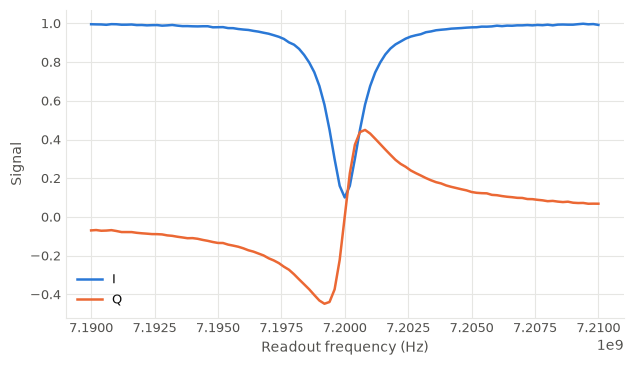

In [27]:
result.plot(m_spec)  # Show both I and Q.
plt.show()

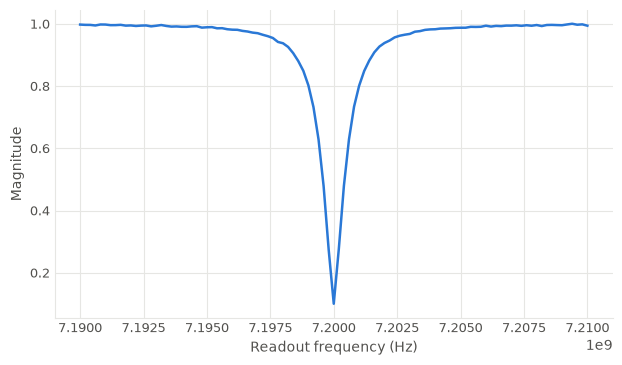

In [28]:
result.plot(m_spec, channels="magnitude")  # Show the magnitude of I + iQ.
plt.show()

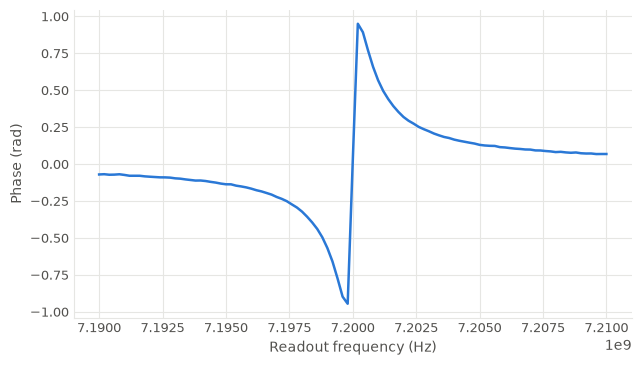

In [29]:
result.plot(m_spec, channels="phase")  # Show the phase of I + iQ.
plt.show()

You can customise a plot through its arguments and the returned Matplotlib `Axes`.

Use `coords=` to change how coordinates are displayed without modifying the stored data. Each entry maps a coordinate name to a `Quantity(label, units, transform)`. For example, displaying frequency in gigahertz requires both `units="GHz"` and a transform that divides the values by `1e9`.

For coordinates that already declare units, provide the new units and the conversion together. Changing only one would make the values and label inconsistent, so the plotting interface rejects it. The following cells demonstrate both errors.

Use `value=` to customise the measured quantity and `style=` for presentation options. Here, `Style(markers=True)` adds a marker at each sample. Any reference lines added through the returned axes must also use the displayed units, so both frequency markers below are expressed in gigahertz.

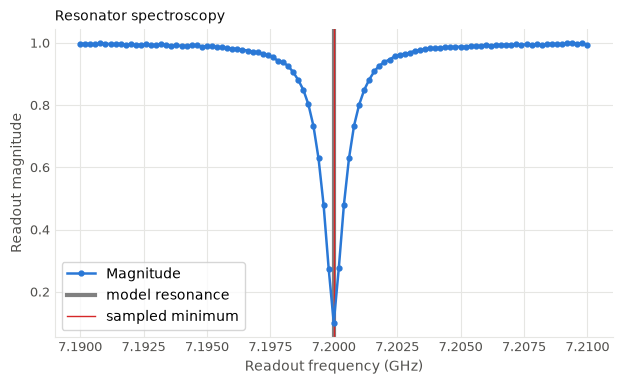

In [30]:
ax = result.plot(
    m_spec,
    channels="magnitude",
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    style=Style(markers=True),
    title="Resonator spectroscopy",
)
# The plot uses GHz, so the reference lines must also use GHz.
ax.axvline(F_READOUT / 1e9, color="grey", linewidth=3, label="model resonance")
ax.axvline(f_dip / 1e9, color="tab:red", linewidth=1, label="sampled minimum")
ax.legend()
plt.show()

In [31]:
# A conversion must also specify the new units.
try:
    result.plot(m_spec, coords={"ro_freq": Quantity(transform=lambda v: v / 1e9)})
except qp.ValidationError as exc:
    print(exc)

coords['ro_freq'] rescales the values, so the inherited unit 'Hz' no longer describes them and the axis would read (Hz) over numbers that are not in Hz. Pass units= for what they are now, units='' if they are now a bare ratio, or units='Hz' if the transform leaves the unit alone, as subtracting a baseline does.


In [32]:
# Changing the units also requires a conversion of the coordinate values.
try:
    result.plot(m_spec, coords={"ro_freq": Quantity(units="GHz")})
except qp.ValidationError as exc:
    print(exc)

coords['ro_freq'] relabels the unit from 'Hz' to 'GHz' without changing the numbers, so the axis would read (GHz) over values still in Hz. Pass the transform= that converts them, or correct the unit on the variable the coordinate came from.


## 2.8 Two nested sweeps

Nest two `with program.sweep(...)` blocks to measure every combination of their values. The outer sweep becomes the first result dimension, and the inner sweep becomes the second.

This example sweeps 21 drive amplitudes and 41 frequencies, producing 861 points. With 200 shots at each point, the model is sampled 172,200 times.

The amplitude variable is passed to the waveform constructor, while the frequency variable is passed to `set_frequency`. This demonstrates the two ways to use variables introduced in section 2.2.

The `p_saturated` function provides a simple Lorentzian response. `F_01` is the assumed true qubit transition frequency, set to 4.85 GHz. `RABI_RATE` converts drive amplitude into a rotation rate, using 40 MHz per DAC unit. In this model, that rate sets the response width, so increasing the amplitude broadens the resonance while its maximum population remains 0.5.

We define these constants beside the model and reuse them when setting the sweep range, displaying frequency offsets, and comparing the estimated width with the model prediction.

In [33]:
F_01 = 4.85e9  # Hz; true qubit transition frequency assumed by the mock model.
RABI_RATE = 40e6  # Hz per DAC unit; converts amplitude to the model's rotation rate.


def p_saturated(bus, env):
    """Return a Lorentzian population response using the swept amplitude and frequency."""
    rabi = RABI_RATE * env["drive_amp"]
    detuning = env["drive_freq"] - F_01
    return 0.5 * rabi**2 / (rabi**2 + detuning**2)


two_tone = qp.QProgram(
    label="qubit_spectroscopy",
    description="Sweep drive amplitude and frequency, then average the classified state.",
    schema=schema,
)
drive_amp = two_tone.variable("drive_amp", label="Drive amplitude", units="DAC units")
drive_freq = two_tone.variable("drive_freq", label="Drive frequency", units="Hz")

with two_tone.average(shots=200):
    with two_tone.sweep(drive_amp, qp.Linspace(0.05, 0.30, 21)):  # Outer dimension: amplitude.
        with two_tone.sweep(drive_freq, qp.Linspace(F_01 - 20e6, F_01 + 20e6, 41)):  # Inner dimension: frequency.
            two_tone.set_frequency(q[0].drive, drive_freq)
            two_tone.play(q[0].drive, IQZero(Square(amplitude=drive_amp, duration=20_000)))
            two_tone.sync([q[0].drive, q[0].readout])
            m_two_tone = two_tone.measure(
                q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,)
            )

# The nested sweeps visit all 21 × 41 combinations.
print(qp.dumps(two_tone))

#!QProgram 0.2

metadata:
  label: "qubit_spectroscopy"
  description: "Sweep drive amplitude and frequency, then average the classified state."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var drive_amp label="Drive amplitude" units="DAC units"
  var drive_freq label="Drive frequency" units="Hz"

  average 200:
    for drive_amp in Linspace(start=0.05, stop=0.3, num=21):
      for drive_freq in Linspace(start=4830000000.0, stop=4870000000.0, num=41):
        set_frequency q[0].drive drive_freq
        play q[0].drive IQZero(envelope=Square(amplitude=drive_amp, duration=20000))
        sync q[0].drive q[0].readout
        measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



In [34]:
map_result = qp.simulate(two_tone, model=qp.MockMeasurementModel(p_excited=p_saturated, seed=11))
population = map_result.get(m_two_tone, field=MeasurementField.STATE)

print("dims:", population.dims)  # drive_amp first, then drive_freq.
print("shape:", population.shape)  # 21 amplitudes × 41 frequencies; shots are averaged.

dims: ('drive_amp', 'drive_freq')
shape: (21, 41)


With two sweep dimensions, `result.plot` produces a heatmap. By default, the inner sweep is shown on the horizontal axis and the outer sweep on the vertical axis. Here, these are frequency and amplitude. The colour represents the excited-state population.

Use `x=` or `y=` to select an axis explicitly; the other dimension is assigned to the remaining axis.

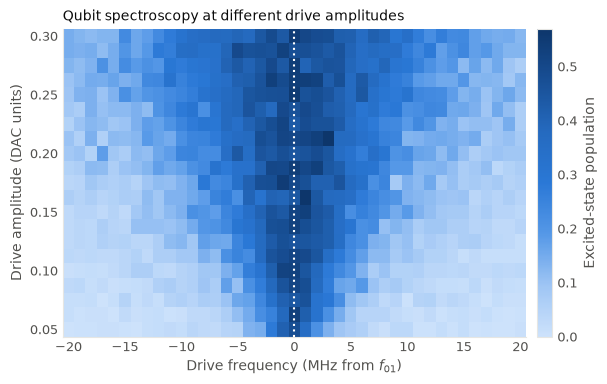

In [35]:
ax_map = map_result.plot(
    m_two_tone,
    field=MeasurementField.STATE,
    coords={
        "drive_freq": Quantity(
            label="Drive frequency",
            units="MHz from $f_{01}$",
            transform=lambda v: (v - F_01) / 1e6,
        ),
    },
    value=Quantity("Excited-state population"),
    title="Qubit spectroscopy at different drive amplitudes",
)
ax_map.axvline(0.0, color="white", linestyle=":")  # Zero detuning is the model resonance.
plt.show()

You can also analyse a single row of the result array. Select an amplitude with `sel`, then use `where(..., drop=True)` to keep only frequencies whose population is at least 0.25, half the model's peak of 0.5. The difference between the highest and lowest retained frequencies estimates the response width.

For this model, the full width at half maximum is `2 * RABI_RATE * amplitude` in hertz. We compare that value with the width estimated from the sampled data.

In [36]:
# Select the row nearest a drive amplitude of 0.175 DAC units.
row = population.sel(drive_amp=0.175, method="nearest")
selected_amp = row.coords["drive_amp"].item()

# Keep the measured points at or above half the model's peak population.
above_half = row.where(row >= 0.25, drop=True)
half_max_frequencies = above_half.coords["drive_freq"]
estimated_width = (half_max_frequencies.max() - half_max_frequencies.min()).item()
model_width = 2 * RABI_RATE * selected_amp

print("drive amplitude:", selected_amp, "DAC units")
print("estimated width:", estimated_width / 1e6, "MHz")
print("model width:", model_width / 1e6, "MHz")

drive amplitude: 0.175 DAC units
estimated width: 14.0 MHz
model width: 14.0 MHz


The estimated widths are affected by both the 1 MHz frequency spacing and the noise from a finite number of shots. A threshold-based estimate uses the sampled frequencies without interpolation, which is particularly limiting for the narrower responses.

## 2.9 Sweeping two variables together

Nested sweeps visit every combination of values. To use pairs of values instead, combine sweeps with `|`:

`program.sweep(a, source_a) | program.sweep(b, source_b)`

The combined block assigns the next value to both variables and executes its shared body once per pair. All sources must have the same length. This requirement is checked when entering the `with` block, rather than when creating the combined sweep object. You can chain more sweeps with additional `|` operators.

The resulting block is a `Parallel` node. Its `.loops` attribute contains the component loops, and `.elements` contains their shared body.

In the result, the variables share one dimension named by joining their identifiers, such as `"a|b"`. Each variable retains its own coordinate array along that dimension. The values at position `k` are paired, so the result does not form a two-dimensional grid.

In [37]:
mismatched = qp.QProgram(label="mismatched", schema=schema)
a = mismatched.variable("a")
b = mismatched.variable("b")

pair_of_loops = mismatched.sweep(a, qp.Linspace(0, 1, 5)) | mismatched.sweep(b, qp.Linspace(0, 1, 6))

# Creating the combined sweep succeeds. Entering it checks the lengths: 5 versus 6.
try:
    with pair_of_loops:
        pass
except qp.ValidationError as exc:
    print(exc)

parallel loops must have the same number of iterations to advance in lockstep; got Sweep('a'): 5, Sweep('b'): 6


The next example selects the frequency with the highest measured population at each amplitude in the previous map. It then pairs those frequencies with their amplitudes in a combined sweep.

This new sweep has 21 points, compared with 861 in the original map. It demonstrates how values extracted from one result can define the sources for a later program. We reuse `p_saturated` with the same `F_01` and `RABI_RATE` values, so both programs measure the same simulated response.

In [38]:
# Extract one amplitude and one peak frequency per row of the previous map.
ridge_amps = population.coords["drive_amp"].values
ridge_freqs = population.idxmax("drive_freq").values  # Frequency coordinate at each row's maximum.

ridge = qp.QProgram(label="qubit_ridge", schema=schema)
r_amp = ridge.variable("drive_amp", label="Drive amplitude", units="DAC units")
r_freq = ridge.variable("drive_freq", label="Drive frequency", units="Hz")

with ridge.average(shots=200):
    # The sweeps advance together, using corresponding entries from the two arrays.
    with ridge.sweep(r_amp, qp.Values(ridge_amps)) | ridge.sweep(r_freq, qp.Values(ridge_freqs)):
        ridge.set_frequency(q[0].drive, r_freq)
        ridge.play(q[0].drive, IQZero(Square(amplitude=r_amp, duration=20_000)))
        ridge.sync([q[0].drive, q[0].readout])
        m_ridge = ridge.measure(q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,))

print(qp.dumps(ridge))

#!QProgram 0.2

metadata:
  label: "qubit_ridge"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var drive_amp label="Drive amplitude" units="DAC units"
  var drive_freq label="Drive frequency" units="Hz"

  average 200:
    for drive_amp in [0.05, 0.0625, 0.07500000000000001, 0.08750000000000001, 0.1, 0.1125, 0.125, 0.1375, 0.15000000000000002, 0.1625, 0.175, 0.1875, 0.2, 0.21250000000000002, 0.22500000000000003, 0.2375, 0.25, 0.2625, 0.275, 0.28750000000000003, 0.3] | for drive_freq in [4850000000.0, 4850000000.0, 4851000000.0, 4850000000.0, 4850000000.0, 4850000000.0, 4849000000.0, 4850000000.0, 4851000000.0, 4851000000.0, 4849000000.0, 4850000000.0, 4852000000.0, 4853000000.0, 4849000000.0, 4849000000.0, 4850000000.0, 4850000000.0, 4850000000.0, 4849000000.0, 4850000000.0]:
      set_frequency q[0].drive drive_freq
      play q[0].drive IQZero(envelope=Square(amplitude=drive_amp, duration=20000))
      sync q[0].drive q[0].readout
      measure q[0].re

In [39]:
ridge_result = qp.simulate(ridge, model=qp.MockMeasurementModel(p_excited=p_saturated, seed=11))
ridge_pop = ridge_result.get(m_ridge, field=MeasurementField.STATE)

print("dims:", ridge_pop.dims)  # One shared dimension: drive_amp|drive_freq.
print("shape:", ridge_pop.shape)  # 21 paired points, rather than an 861-point grid.
print(ridge_pop.coords)  # Both variables retain their own coordinate values.

dims: ('drive_amp|drive_freq',)
shape: (21,)
Coordinates:
    drive_amp   (drive_amp|drive_freq) float64 168B 0.05 0.0625 ... 0.2875 0.3
    drive_freq  (drive_amp|drive_freq) float64 168B 4.85e+09 ... 4.85e+09


For a combined sweep, the default plot displays the first variable on the bottom axis and the second on a top axis. Both axes use the same sample positions. The top labels can repeat when several paired points have the same frequency.

You can customise each coordinate independently through `coords=`. Below, the amplitude keeps its original units, while frequency is displayed as an offset from `F_01` in megahertz.

The model predicts a population of 0.5 at resonance. The plotted values vary around the response at the selected frequencies because each point averages a finite number of shots. A horizontal reference line marks 0.5, and fixed vertical limits make the variation easier to assess.

To display only one coordinate axis, select it with `x=`. Once a coordinate is omitted from the plot, including it in `coords=` raises a validation error.

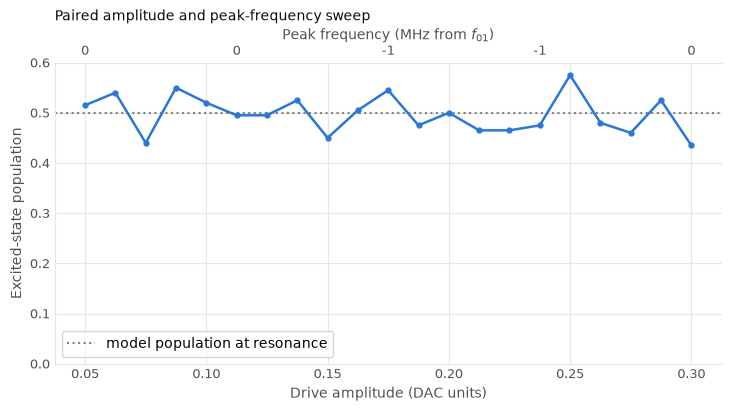

In [40]:
ax_ridge = ridge_result.plot(
    m_ridge,
    field=MeasurementField.STATE,
    coords={
        "drive_freq": Quantity(
            label="Peak frequency",
            units="MHz from $f_{01}$",
            transform=lambda v: (v - F_01) / 1e6,
        ),
    },
    value=Quantity("Excited-state population"),
    style=Style(markers=True),
    title="Paired amplitude and peak-frequency sweep",
)
ax_ridge.set_ylim(0.0, 0.6)
ax_ridge.axhline(0.5, color="grey", linestyle=":", label="model population at resonance")
ax_ridge.legend()
plt.show()

In [41]:
# x="drive_amp" omits the frequency axis, so coords cannot customise that axis.
try:
    ridge_result.plot(
        m_ridge,
        field=MeasurementField.STATE,
        x="drive_amp",
        coords={"drive_freq": Quantity(units="Hz")},
    )
except qp.ValidationError as exc:
    print(exc)

coords['drive_freq'] names a coordinate this figure does not draw. This line draws: 'drive_amp' (the x axis). The measured quantity is not keyed here — name it with value=Quantity(...). Coordinates on this result: drive_amp, drive_freq.


### 🧩 Exercise 2.1

Create a program that sweeps the amplitude of a drive pulse at a fixed frequency. Use the result to estimate the amplitude of a pi pulse and plot the measured population.

The supplied `p_rabi` model produces a sine-squared response. Its constant `A_PI`, defined beside the function, is the assumed true pi-pulse amplitude in DAC units. We set it to 0.62 and use it both to generate the mock data and to check the estimate. The model provides measurement values without simulating the pulse dynamics.

1. Create a new transmon schema using `BusSchema.transmon()`. Assign it to `schema` and use `q = schema.q` to access its qubit buses.
2. Create a program labelled `exercise-2.1` using your new schema. Declare an amplitude variable with the identifier `amp`, a readable label, and `units="DAC units"`. The model accesses this variable as `env["amp"]`.
3. Use `average(shots=200)` around a linear sweep of 41 amplitudes from 0.0 to 1.0.
4. Inside the sweep, set the drive frequency to `F_01`, the qubit frequency defined in section 2.8. Play an `IQDrag` waveform with the variable as its amplitude, `duration=40`, `sigma=10`, and `beta=0.15`.
5. Synchronise the drive and readout buses. Measure the readout bus using the aliases `"readout"` and `"weights"`, requesting only `MeasurementField.STATE`. Store the measurement handle.
6. Simulate the program with `qp.MockMeasurementModel(p_excited=p_rabi, seed=17)`. Retrieve the state result and print its dimensions and shape.
7. Select amplitudes from 0.0 to 0.5 using this result's `amp` coordinate. Calculate the absolute difference from population 0.5, then use `idxmin("amp")` to find the amplitude with the smallest difference. Double that amplitude to estimate the pi-pulse amplitude and compare it with `A_PI`.
8. Plot the population with a marker at each sample and a descriptive value-axis label. Add a dashed vertical line at the estimated pi-pulse amplitude using the returned axes.

The estimate in step 7 uses the rising part of the sine-squared curve. At population 0.5, the slope is steeper than at the peak, making the amplitude less sensitive to small population changes. The finite sweep spacing and measurement noise still affect the estimate. No coordinate conversion is needed because the amplitude variable already declares DAC units.

Uncomment the hints below and replace each `...` with the missing code. Some gaps need several operations.

In [42]:
A_PI = 0.62  # DAC units; true pi-pulse amplitude assumed by the mock model.


def p_rabi(bus, env):
    """Return a sine-squared population response with its first maximum at A_PI."""
    return np.sin(np.pi * env["amp"] / (2 * A_PI)) ** 2

In [ ]:
# schema = ...
# q = ...
#
# rabi = qp.QProgram(label="exercise-2.1", schema=...)
# r_pulse_amp = rabi.variable("amp", label=..., units=...)
#
# with rabi.average(shots=...):
#     with rabi.sweep(r_pulse_amp, ...):
#         ...
#         m_rabi = rabi.measure(...)
#
# rabi_result = qp.simulate(rabi, model=...)
# rabi_pop = rabi_result.get(...)
# ...
#
# rising = rabi_pop.sel(amp=...)
# distance_from_half = ...
# half_amp = distance_from_half.idxmin("amp").item()
# a_pi_found = ...
# ...
#
# ax_rabi = rabi_result.plot(...)
# ax_rabi.axvline(...)
# ...

## Recap

- Declare variables with `program.variable(...)`. Their identifiers name sweep dimensions, while their labels and units provide plot metadata.
- Build expressions from variables to parameterise operations and waveforms. Expressions use the variables' current values when evaluated.
- Define sweeps with source objects or `from_*` builder methods. Use `Range` or `Linspace` to declare a linear sequence and `Values` for explicit values.
- Use `average(shots)` to average repeated measurements without adding a shot dimension. Averaged classified states estimate the probability of state 1.
- Supply simulated measurements with `qp.MockMeasurementModel` or a custom object implementing `sample(bus, env)`.
- Retrieve results as `xarray.DataArray` objects using a handle, name, or index. Nested sweeps create separate dimensions; sweeps combined with `|` share one dimension with multiple coordinates. Integrated results also include an `IQ` dimension.
- Use `result.plot` to display the data, customise quantities and units through `Quantity`, and add annotations through the returned axes.

## Next

**Advanced** covers language extensions and platform definitions. Its six sections are independent, so you can read them in the order most relevant to your work.